In [3]:
!pip install xlrd

  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)


Valeurs manquantes :
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Top États par ventes :
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


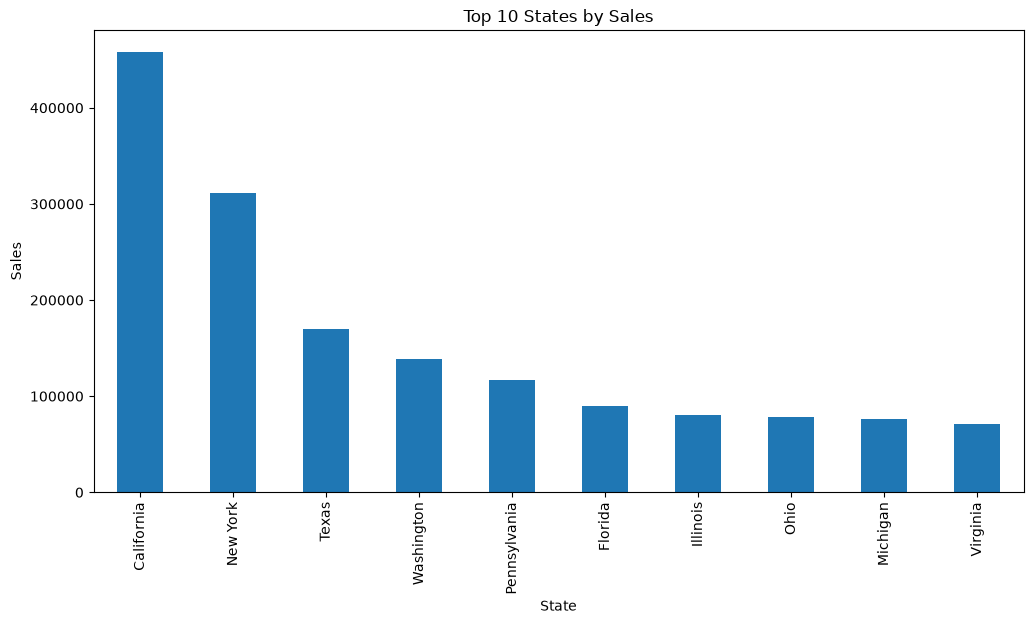


Comparaison New York vs California :
                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


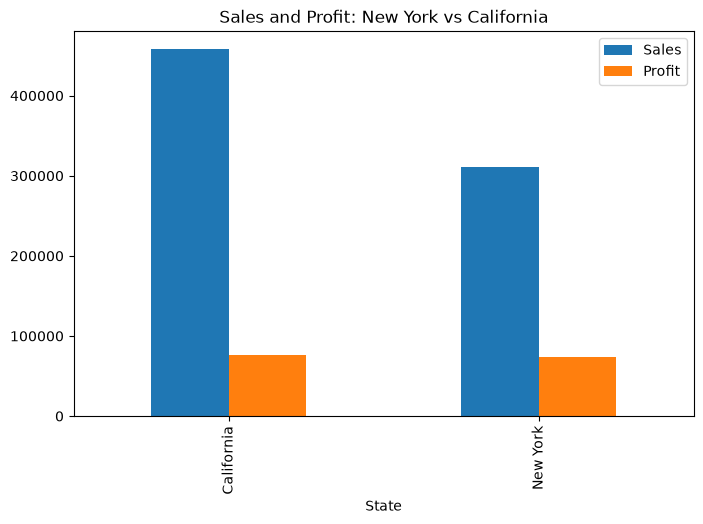


Outstanding Customer in New York :
Customer Name
Tom Ashbrook    13723.498
Name: Sales, dtype: float64

Profit par État :
State
California              76381.3871
New York                74038.5486
Washington              33402.6517
Michigan                24463.1876
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1

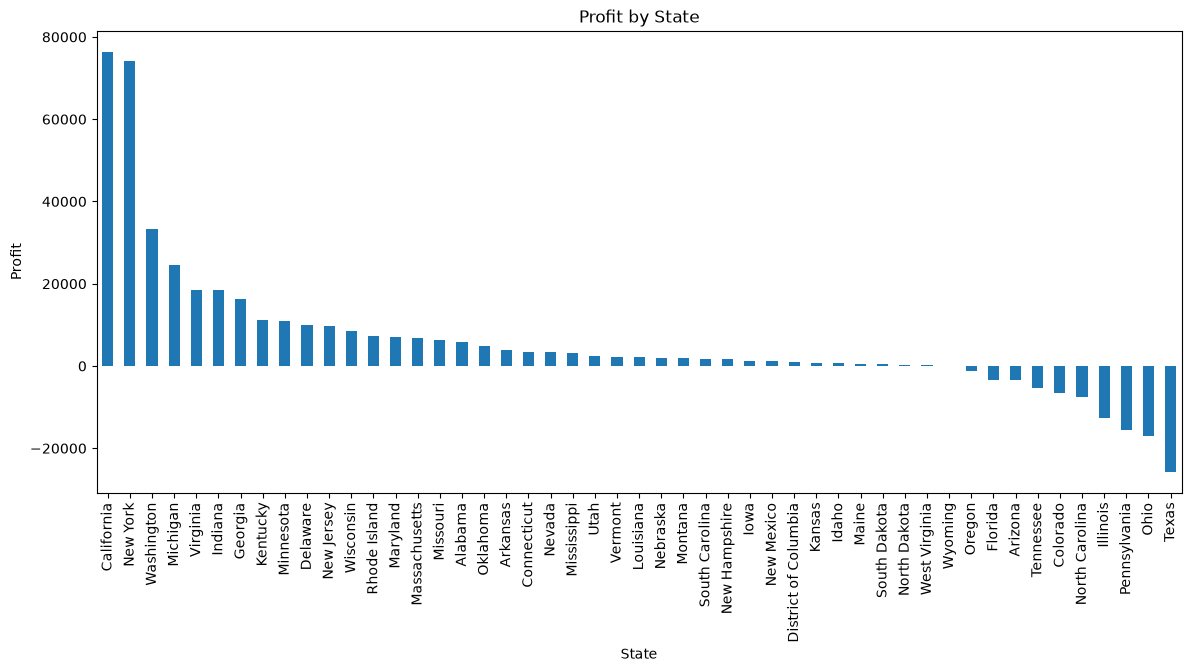


Pareto - Profit
Les 20% meilleurs clients génèrent 81.43% du profit total.

Top 20 Cities by Sales :
City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


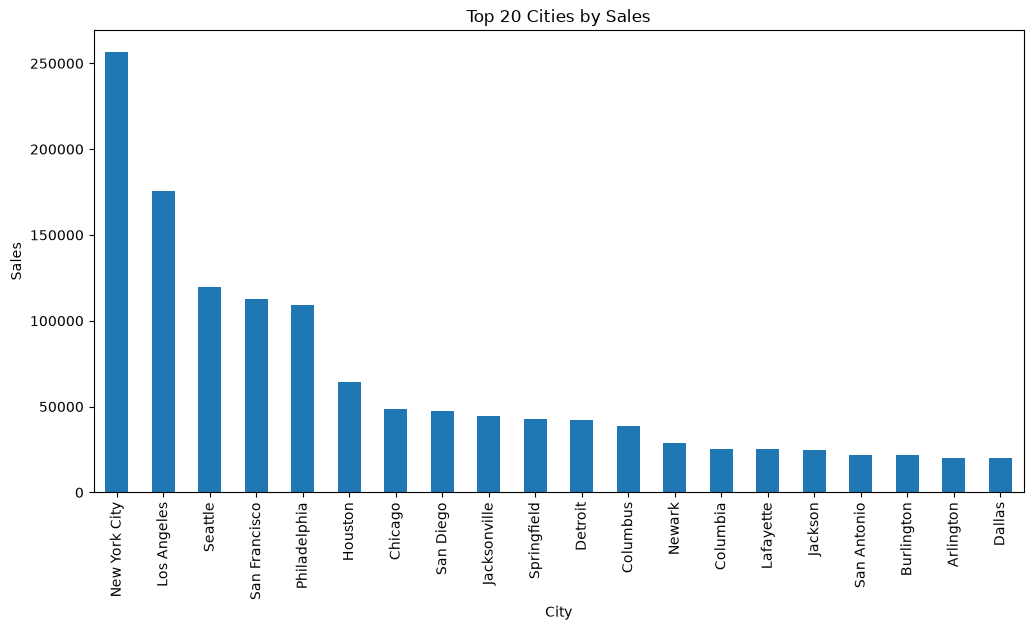


Top 20 Cities by Profit :
City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


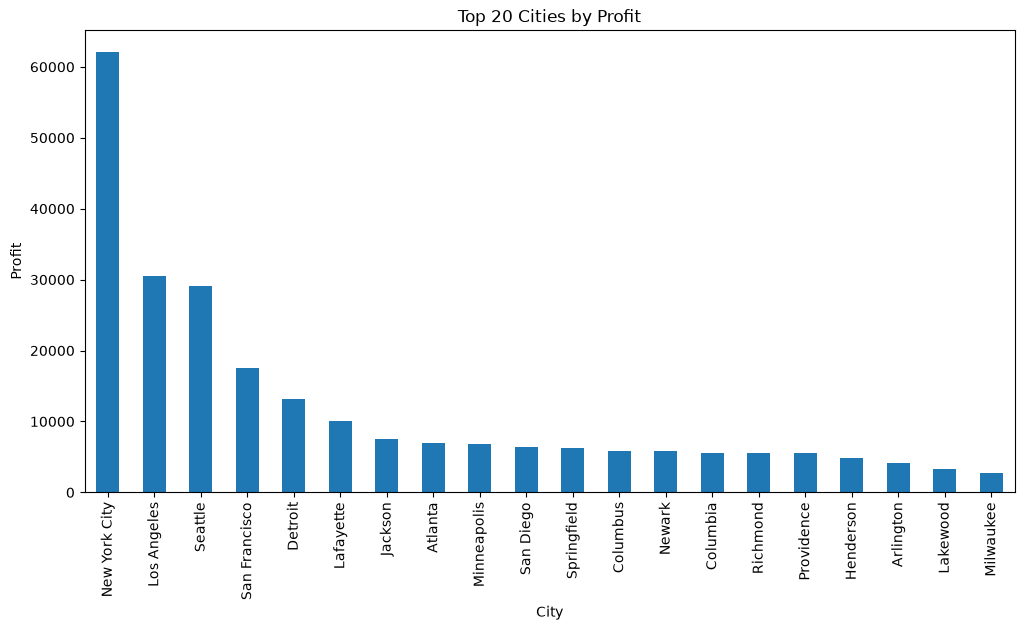


Top villes les plus rentables :
                 Sales    Profit  Profitability
City                                           
Atlantic City   23.360   11.6800       0.500000
Grand Island    15.960    7.9800       0.500000
New Brunswick   14.770    7.1567       0.484543
Summerville    406.940  196.9132       0.483888
Holland        137.860   66.6588       0.483525
Antioch         19.440    9.3312       0.480000
Lindenhurst     55.480   26.6304       0.480000
Royal Oak       35.340   16.9632       0.480000
Davis           32.400   15.5520       0.480000
Bozeman         43.660   20.8106       0.476651
San Clemente    90.058   42.5419       0.472383
Layton           4.960    2.3312       0.470000
Hagerstown      43.800   20.5860       0.470000
San Mateo       75.180   35.3346       0.470000
Gulfport       166.500   77.5761       0.465923
East Orange    377.270  174.6191       0.462849
Rogers          40.410   18.5886       0.460000
Norfolk         17.430    8.0178       0.460000
Iowa Ci

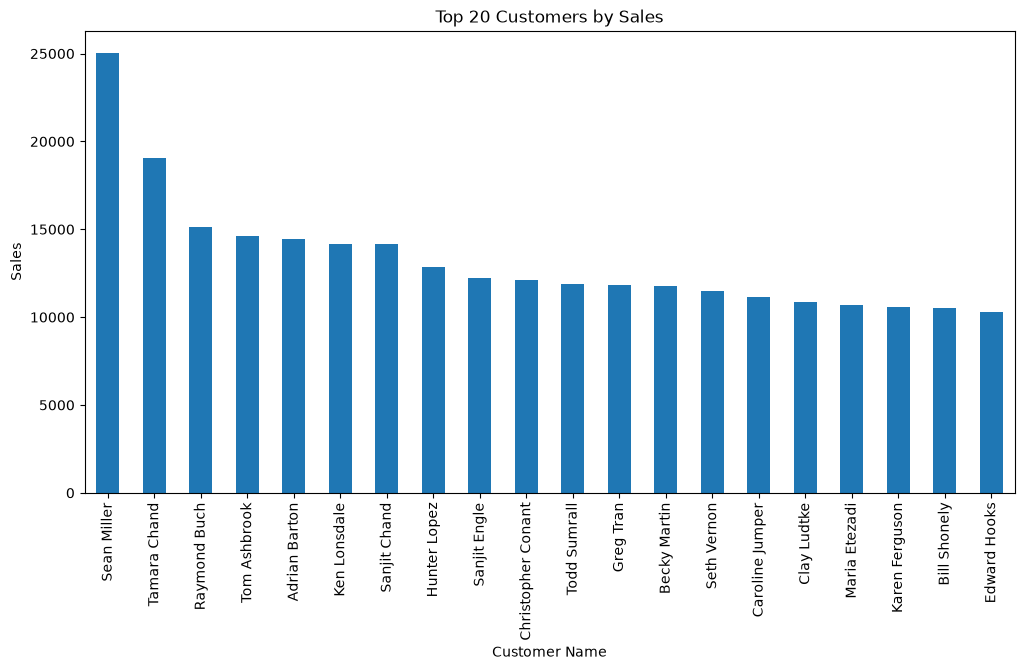

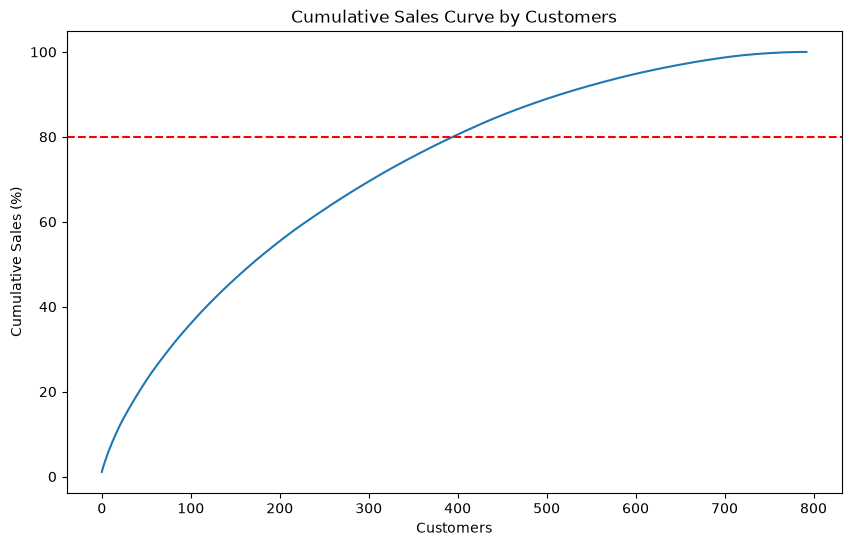


Pareto - Sales
Les 20% meilleurs clients génèrent 47.96% des ventes totales.

RECOMMANDATIONS MARKETING
- Prioriser les États ayant les ventes les plus élevées.
- Prioriser les villes ayant simultanément de fortes ventes et de forts profits.
- Fidéliser les meilleurs clients générant la majorité des ventes et profits.
- Renforcer les investissements marketing dans les zones les plus rentables.


In [8]:
# ============================================================
# MINI-PROJECT : DATA ANALYSIS FOR MARKETING STRATEGY
# ============================================================

# Importer les bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Charger et prétraiter le dataset
# ------------------------------------------------------------
df = pd.read_excel("Superstore.xls", engine="xlrd")

# Conversion des colonnes de dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Vérification rapide des valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum())

# ============================================================
# 2. Quels États ont le plus de ventes ?
# ============================================================
sales_by_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

print("\nTop États par ventes :")
print(sales_by_state.head(10))

plt.figure(figsize=(12,6))
sales_by_state.head(10).plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.ylabel('Sales')
plt.show()

# ============================================================
# 3. Différence entre New York et California en ventes et profit
# ============================================================
ny_ca = df[df['State'].isin(['New York', 'California'])]

comparison = ny_ca.groupby('State')[['Sales', 'Profit']].sum()

print("\nComparaison New York vs California :")
print(comparison)

comparison.plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit: New York vs California')
plt.show()

# ============================================================
# 4. Qui est un client remarquable (outstanding customer)
#    à New York ?
# ============================================================
ny_customers = (
    df[df['State'] == 'New York']
    .groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print("\nOutstanding Customer in New York :")
print(ny_customers.head(1))

# ============================================================
# 5. Y a-t-il des différences de rentabilité entre les États ?
# ============================================================
profit_by_state = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

print("\nProfit par État :")
print(profit_by_state)

plt.figure(figsize=(14,6))
profit_by_state.plot(kind='bar')
plt.title('Profit by State')
plt.ylabel('Profit')
plt.show()

# ============================================================
# 6. Peut-on appliquer le principe de Pareto aux clients
#    et au Profit ?
# ============================================================
customer_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)

total_customers = len(customer_profit)
top_20_percent_customers = int(total_customers * 0.20)

profit_top_20 = customer_profit.head(top_20_percent_customers).sum()
profit_percentage = (profit_top_20 / customer_profit.sum()) * 100

print("\nPareto - Profit")
print(f"Les 20% meilleurs clients génèrent {profit_percentage:.2f}% du profit total.")

# ============================================================
# 7. Top 20 villes par ventes
# ============================================================
top20_sales_cities = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop 20 Cities by Sales :")
print(top20_sales_cities)

plt.figure(figsize=(12,6))
top20_sales_cities.plot(kind='bar')
plt.title('Top 20 Cities by Sales')
plt.ylabel('Sales')
plt.show()

# ============================================================
# 8. Top 20 villes par profit# 8. Top 20 villes par profit
# ============================================================
top20_profit_cities = (
    df.groupby('City')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop 20 Cities by Profit :")
print(top20_profit_cities)

plt.figure(figsize=(12,6))
top20_profit_cities.plot(kind='bar')
plt.title('Top 20 Cities by Profit')
plt.ylabel('Profit')
plt.show()

# ============================================================
# 9. Différences de rentabilité entre les villes
# ============================================================
city_profitability = (
    df.groupby('City')[['Sales', 'Profit']]
    .sum()
)

city_profitability['Profitability'] = (
    city_profitability['Profit'] / city_profitability['Sales']
)

print("\nTop villes les plus rentables :")
print(city_profitability.sort_values('Profitability', ascending=False).head(20))

print("\nVilles les moins rentables :")
print(city_profitability.sort_values('Profitability').head(20))

# ============================================================
# 10. Top 20 clients par ventes
# ============================================================
top20_customers_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop 20 Customers by Sales :")
print(top20_customers_sales)

plt.figure(figsize=(12,6))
top20_customers_sales.plot(kind='bar')
plt.title('Top 20 Customers by Sales')
plt.ylabel('Sales')
plt.show()

# ============================================================
# 11. Courbe cumulative des ventes par client
# ============================================================
customer_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

cumulative_sales_percent = (
    customer_sales.cumsum() / customer_sales.sum()
) * 100

plt.figure(figsize=(10,6))
plt.plot(cumulative_sales_percent.values)
plt.axhline(y=80, color='red', linestyle='--')
plt.title('Cumulative Sales Curve by Customers')
plt.xlabel('Customers')
plt.ylabel('Cumulative Sales (%)')
plt.show()

# ============================================================
# 12. Peut-on appliquer le principe de Pareto aux clients
#     et aux ventes ?
# ============================================================
sales_top_20 = customer_sales.head(top_20_percent_customers).sum()
sales_percentage = (sales_top_20 / customer_sales.sum()) * 100

print("\nPareto - Sales")
print(f"Les 20% meilleurs clients génèrent {sales_percentage:.2f}% des ventes totales.")

# ============================================================
# 13. Décisions marketing
# ============================================================
print("\nRECOMMANDATIONS MARKETING")

print("- Prioriser les États ayant les ventes les plus élevées.")
print("- Prioriser les villes ayant simultanément de fortes ventes et de forts profits.")
print("- Fidéliser les meilleurs clients générant la majorité des ventes et profits.")
print("- Renforcer les investissements marketing dans les zones les plus rentables.")
